# Results plots for a premerger analysis with gaps

Realistic LISA data will have gaps. The extent to which is not yet know, but there will be quite a few. So we have to be able to ride these out.

In [1]:
# This stuff only actually gets used in this cell:

from matplotlib import pyplot as plt

# Use the style file defined in the repository route
plt.style.use('../../paper.mplstyle')

# This is the folder where results plots will be saved:
paper_plots_dir = '../../paper/images/inpainting_results'

# The common and plotting utils modules are in the parent
# `search` directory
# Here we add the `search` directory to the python path so we can
# do a local import

import sys
import os
import numpy as np

parent_dir = os.path.abspath("..")

if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)


# Everything plotted in this notebook is done using these helper modules
import plotting_utils
from common_utils import get_results_inpainting as get_results, get_results_zero_latency

/Users/gareth/miniconda3/envs/env_lisa_premerger_sangria/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


Lets imagine that there are gaps before signal zero. Inpainting rides them out, the zero latency filter doesn't.

In [ ]:

# For signal zero - plot the results filtered for the closest to the predicted merger time
example_signal = 0

# Get the truth times
import ldc.io.hdf5 as hdfio

input_data = '../../datasets/LDC2_sangria_hm_training.hdf'
mbhb_sky = hdfio.load_array(input_data, name="sky/mbhb/cat")

truth_times_s = mbhb_sky[0]['CoalescenceTime']

## Load results
We are going to compare the two searches, and a special inpainting run around signal 0 with gaps.

### Zero latency results

We are going to compare to the zero latency results, so load these in. We want to get the result from X days before merger to add to the plot. We could index juggle to get this really efficiently, but lets just use the closest point as its easier to implement.

In [ ]:
times_before = [0.5, 1, 4, 7, 14]

# Load the zero-latency results
results_zero_latency = get_results_zero_latency(
    "../zero_latency/results/psd_estimate/data_runs_raw_{time_before}_results.hdf",
    times_before
)

In [ ]:
# Filter the zero latency results to only use the closest point for each

zl_results_data_end_time = []
zl_results_snr = []

for t_before in times_before:
    this_t = results_zero_latency['time_before'] == t_before
    closest_match = np.argmin(
        abs(results_zero_latency['time'][this_t] - truth_times_s[example_signal])
    )
    zl_results_data_end_time.append(results_zero_latency['data_end_time'][this_t][closest_match])
    zl_results_snr.append(results_zero_latency['snr'][this_t][closest_match])

zl_results_data_end_time = np.array(zl_results_data_end_time)
zl_results_snr = np.array(zl_results_snr)

### Inpainting results

We do the same for the inpainting results - load and filter

In [ ]:
# We need to get the inpainting results again which have not been filtered for particular times-before-merger
results_estimate_all = get_results(
    f"results/data_runs_psd_estimate.hdf"
)

ip_times_before = np.unique(results_estimate_all['time_before'])
ip_results_data_end_time = []
ip_results_snr = []
for t_before in ip_times_before:
    this_t = results_estimate_all['time_before'] == t_before
    closest_match = np.argmin(
        abs(results_estimate_all['time'][this_t] - truth_times_s[example_signal])
    )
    ip_results_data_end_time.append(results_estimate_all['data_end_time'][this_t][closest_match])
    ip_results_snr.append(results_estimate_all['snr'][this_t][closest_match])

ip_results_data_end_time = np.array(ip_results_data_end_time)
ip_results_snr = np.array(ip_results_snr)



### Gaps results

We ran a special run with some gaps defined just before signal 0. Load these in, again filter to the ones relevant to this signal.

In [ ]:
# A special run around signal 0 which has gaps inserted
inpainting_gaps_results = get_results(
    "results/data_runs_signal_0_gaps.hdf",
)

ipg_times_before = np.unique(inpainting_gaps_results['time_before'])
ipg_results_data_end_time = []
ipg_results_snr = []
for t_before in ip_times_before:
    this_t = inpainting_gaps_results['time_before'] == t_before
    closest_match = np.argmin(
        abs(inpainting_gaps_results['time'][this_t] - truth_times_s[example_signal])
    )
    ipg_results_data_end_time.append(inpainting_gaps_results['data_end_time'][this_t][closest_match])
    ipg_results_snr.append(inpainting_gaps_results['snr'][this_t][closest_match])

ipg_results_data_end_time = np.array(ipg_results_data_end_time)
ipg_results_snr = np.array(ipg_results_snr)

## Figure 8

Now plot these results together to compare the two runs and the special signal 0 with gaps

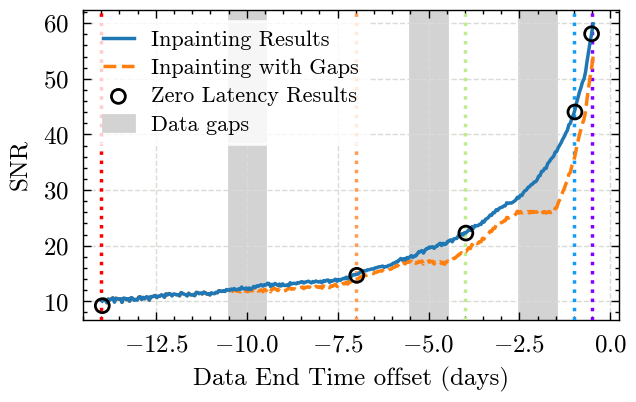

In [ ]:


width = plt.rcParams["figure.figsize"][0]
height = plt.rcParams["figure.figsize"][1]

fig, ax = plt.subplots(1, figsize=(width, height),)

# inpainting results
ax.plot(
    (ip_results_data_end_time - truth_times_s[example_signal]) / 86400,
    ip_results_snr,
    linewidth=1.25,
    color='tab:blue',
    label='Inpainting Results',
    zorder=10
)
# inpainting with gaps, should lay on top of each other, then diverge during the gaps,
# and then be pretty much parallel / after / in between the gaps.
ax.plot(
    (ipg_results_data_end_time - truth_times_s[example_signal]) / 86400,
    ipg_results_snr,
    linewidth=1.25,
    color='tab:orange',
    linestyle='--',
    label='Inpainting with Gaps',
    zorder=8
)

# Add some circles on for the inpainting results.
ax.scatter(
    (zl_results_data_end_time - truth_times_s[example_signal]) / 86400,
    zl_results_snr,
    edgecolor='k',
    marker='o',
    facecolors='none',
    label='Zero Latency Results',
    zorder=20

)

# Add on some dotted lines for the time-before-merger
sm = plotting_utils.get_sm(vmin=min(times_before), vmax=max(times_before))

for time_before in times_before:
    ax.axvline(
        -time_before,
        c=sm.to_rgba(time_before),
        linestyle=':',
        linewidth=1.25,
        zorder=5
    )

# Add grey regions for the gaps behond the lines / scatters
for gap in [(2.5, 1.5), (5.5, 4.5), (10.5, 9.5)]:
    ax.axvspan(-gap[0], -gap[1], color='lightgray', zorder=0)
# This one is for the legend, so is way off the edge of the plot
ax.axvspan(100, 100, color='lightgray', zorder=0, label='Data gaps')

ax.grid(zorder=0)
ax.set_xlim(-14.5, 0.25)
ax.legend(loc='upper left')
ax.set_ylabel('SNR')
ax.set_xlabel('Data End Time offset (days)')
fig.savefig(f'{paper_plots_dir}/figure_8_signal_{example_signal}_timeline.png', dpi=300)

In [5]:
# In the paper we discuss where the signal 0 lines cross SNR of 40, let's find where this happens:
# Note that this is the hourly results, so results may vary by up to an hour (~0.04 days)

crossing_snr = 40

crossing_ip_idx = np.argwhere(ip_results_snr > crossing_snr)[-1][0]
crossing_ip_time = (ip_results_data_end_time[crossing_ip_idx] - truth_times_s[0]) / 86400
print(f'First inpainting result with SNR > {crossing_snr} at {-crossing_ip_time:.3f} days')

crossing_ipg_idx = np.argwhere(ipg_results_snr > crossing_snr)[-1][0]
crossing_ipg_time = (ipg_results_data_end_time[crossing_ipg_idx] - truth_times_s[0]) / 86400
print(f'First inpainting + gaps result with SNR > {crossing_snr} at {-crossing_ipg_time:.3f} days')
crossing_ipg_idx = np.argwhere(ipg_results_snr > crossing_snr)[-1][0]

crossing_zl_idx = np.argwhere(zl_results_snr > crossing_snr)[-1][0]
crossing_zl_time = (zl_results_data_end_time[crossing_zl_idx] - truth_times_s[0]) / 86400
print(f'First zero latency result with SNR > {crossing_snr} at {-crossing_zl_time:.3f} days')

First inpainting result with SNR > 40 at 1.222 days
First inpainting + gaps result with SNR > 40 at 0.806 days
First zero latency result with SNR > 40 at 0.972 days


## Timeline plots for all signals

Make some timeline plots for all signals - we don't have gaps in the Sangria dataset, so these dont show up here, but we can show the SNR buildup over time for everything.

These plots use the removal 2 hours before merger results, so for signals 2-5 this may not be the best accuracy

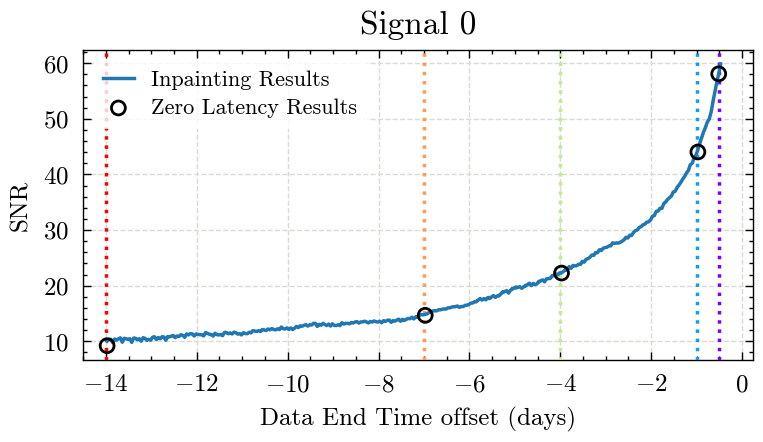

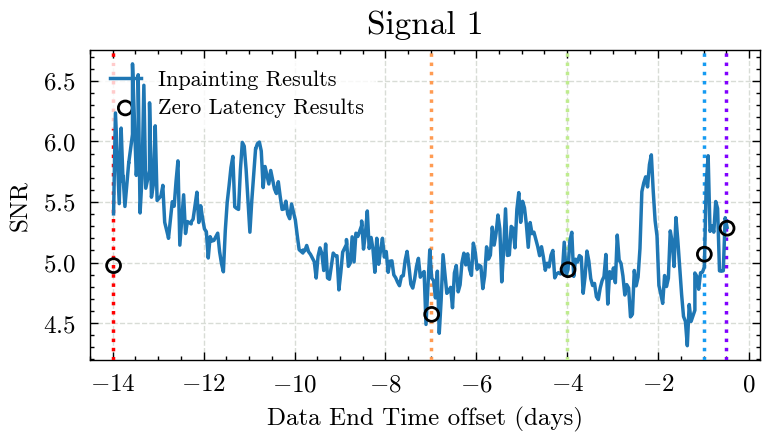

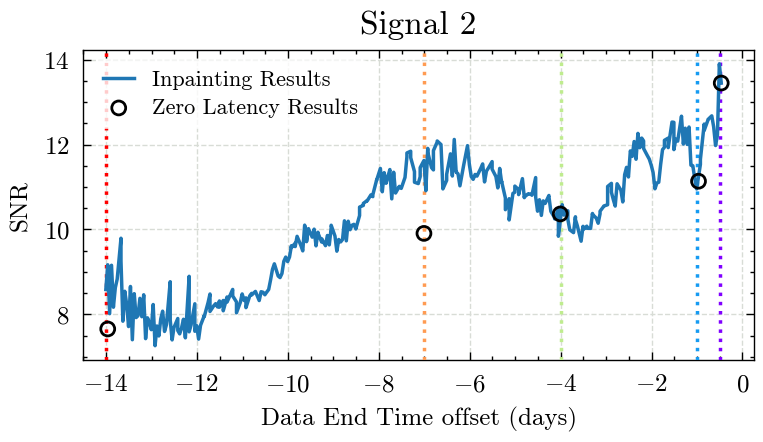

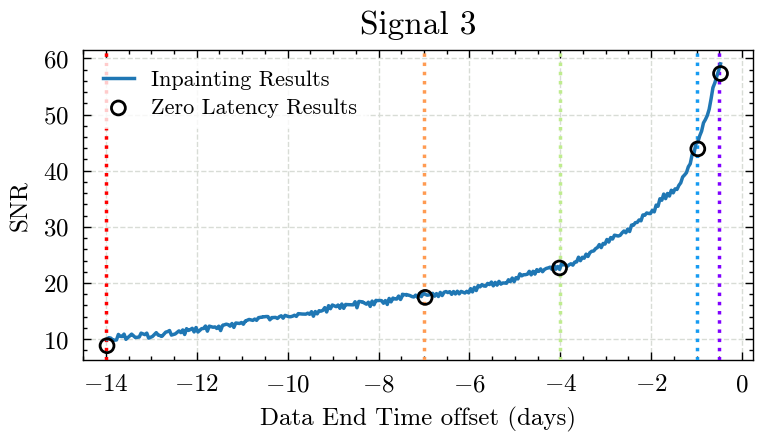

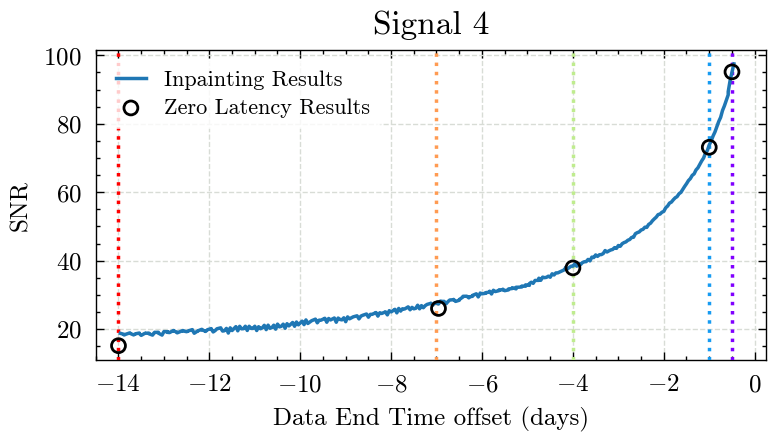

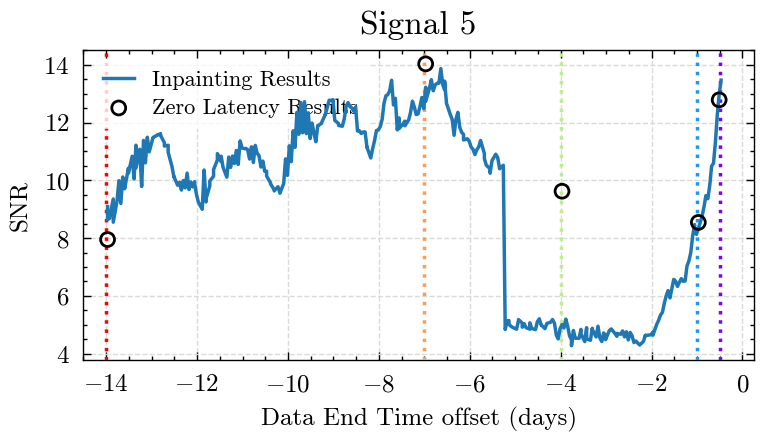

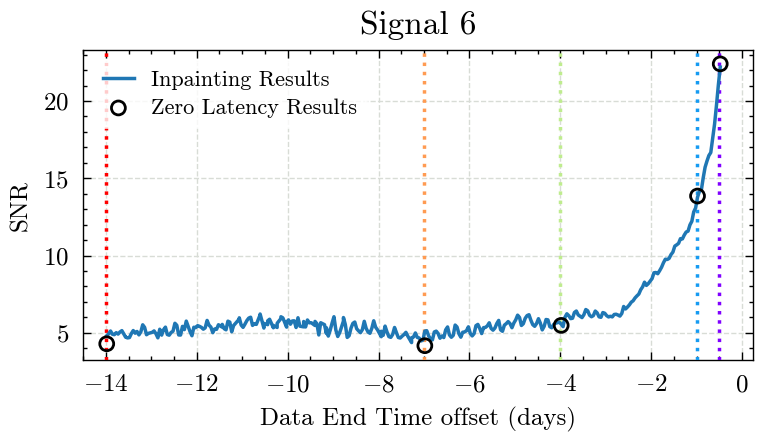

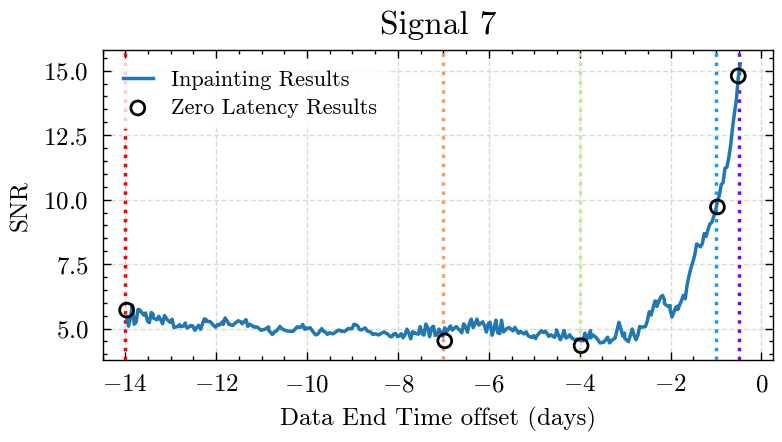

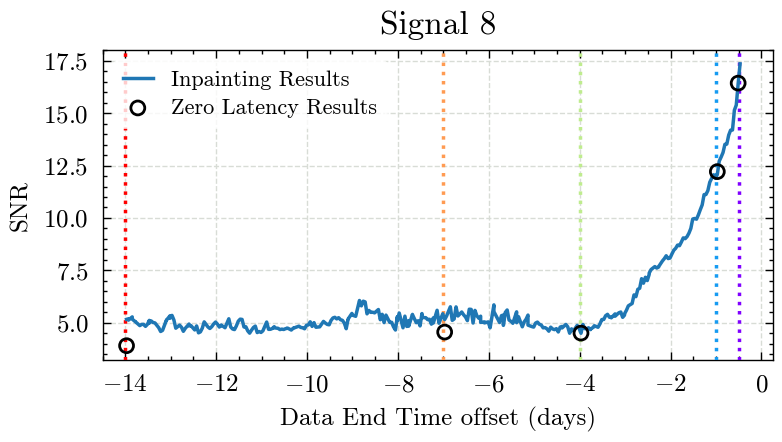

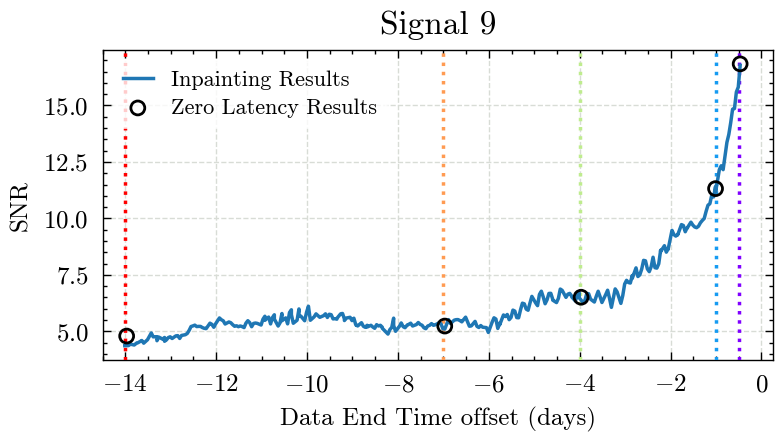

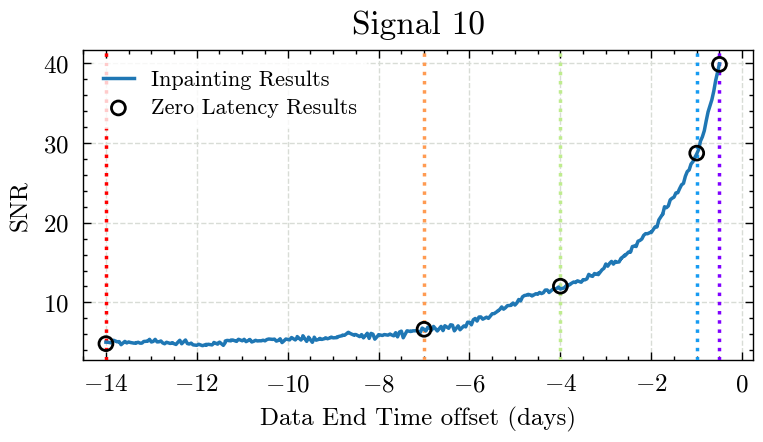

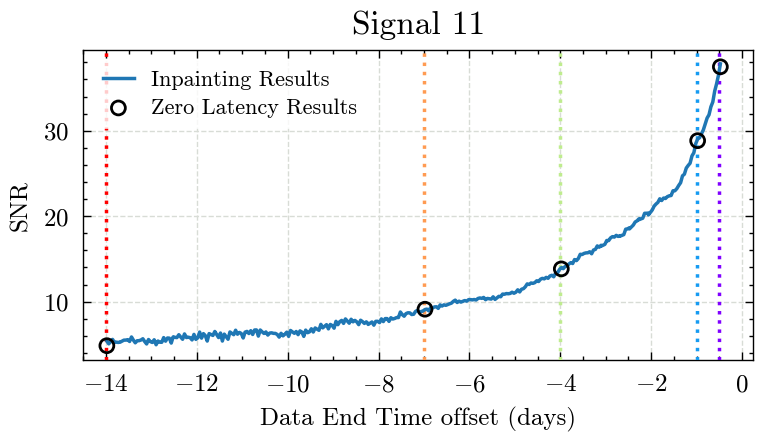

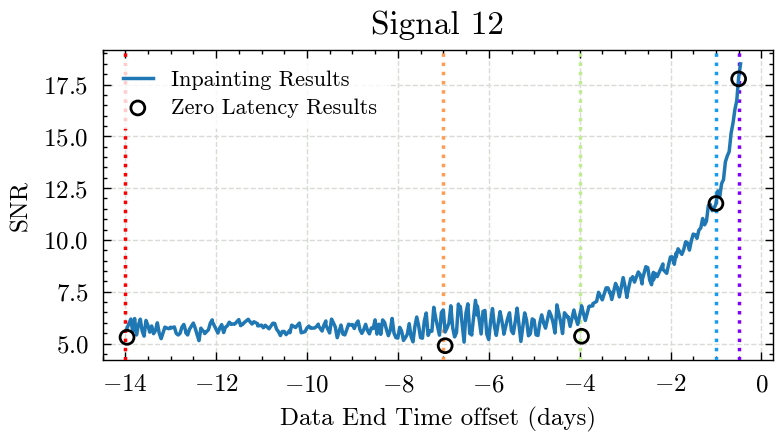

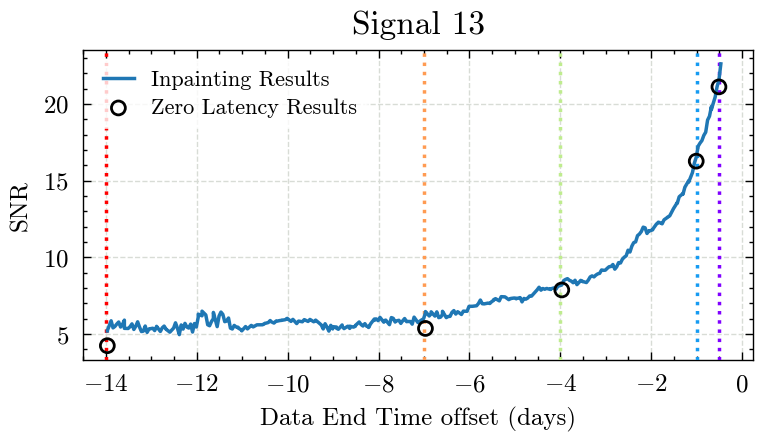

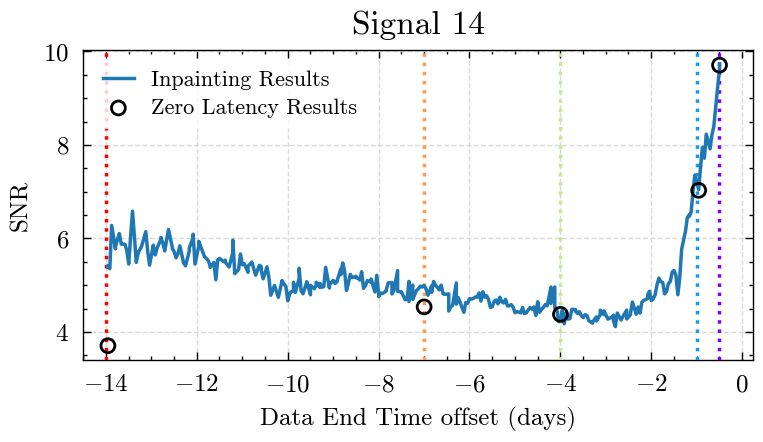

In [6]:

for signal_number in np.arange(15):

    # Filter the zero latency results to only use the closest point for each time before merger
    zl_data_end_time = []
    zl_snr = []

    for t_before in times_before:
        this_t = results_zero_latency['time_before'] == t_before
        closest_match = np.argmin(
            abs(results_zero_latency['time'][this_t] - truth_times_s[signal_number])
        )
        zl_data_end_time.append(results_zero_latency['data_end_time'][this_t][closest_match])
        zl_snr.append(results_zero_latency['snr'][this_t][closest_match])

    zl_data_end_time = np.array(zl_data_end_time)
    zl_snr = np.array(zl_snr)


    ip_times_before = np.unique(results_estimate_all['time_before'])
    ip_data_end_time = []
    ip_snr = []
    for t_before in ip_times_before:
        this_t = results_estimate_all['time_before'] == t_before
        closest_match = np.argmin(
            abs(results_estimate_all['time'][this_t] - truth_times_s[signal_number])
        )
        ip_data_end_time.append(results_estimate_all['data_end_time'][this_t][closest_match])
        ip_snr.append(results_estimate_all['snr'][this_t][closest_match])

    ip_data_end_time = np.array(ip_data_end_time)
    ip_snr = np.array(ip_snr)

    width = plt.rcParams["figure.figsize"][0] * 1.25
    height = plt.rcParams["figure.figsize"][1]

    fig, ax = plt.subplots(1, figsize=(width, height),)

    ax.plot(
        (ip_data_end_time - truth_times_s[signal_number]) / 86400,
        ip_snr,
        linewidth=1.25,
        color='tab:blue',
        label='Inpainting Results',
        zorder=10
    )

    ax.scatter(
        (zl_data_end_time - truth_times_s[signal_number]) / 86400,
        zl_snr,
        edgecolor='k',
        marker='o',
        facecolors='none',
        label='Zero Latency Results',
        zorder=20

    )

    sm = plotting_utils.get_sm(vmin=min(times_before), vmax=max(times_before))

    for time_before in times_before:
        ax.axvline(
            -time_before,
            c=sm.to_rgba(time_before),
            linestyle=':',
            linewidth=1.25,
            zorder=5
        )

    ax.grid(zorder=0)
    ax.set_xlim(-14.5, 0.25)
    ax.set_title(f'Signal {signal_number}')
    ax.legend(loc='upper left')
    ax.set_ylabel('SNR')
    ax.set_xlabel('Data End Time offset (days)')